<br/>

<div align="center">
<span style="font-size: 2.5em;">SBI Training Results and Inference</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Visualization of trained WimPy models and posterior inference</span>
</div>

## Overview

This notebook visualizes the training results and demonstrates inference capabilities of trained SBI models for WIMP parameter estimation.

**Workflow:**

1. **Setup**: Load trained model and prepare datasets
2. **Training Analysis**: Visualize loss and accuracy curves from training
3. **Single Posterior**: Generate and plot posterior for a specific parameter combination
4. **Grid Posteriors**: Generate posteriors across a grid of parameter values

**Note:** Model training is performed via the `training_wimpy.py` script. This notebook focuses on result visualization and inference demonstration.

## 1. Setup and Configuration

Import required libraries and set up paths to access the project modules.

In [10]:
import os
desired_root_name = "xenon-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import matplotlib.pyplot as plt
import numpy as np

from configs.config import load_model, PARAM_RANGES
from utils.training import plot_training_summary
from utils.posteriors import (
    plot_posterior_single, 
    plot_posterior_double,
    plot_posterior_grid,
    plot_null_exclusion,
 )
from utils.processing import preprocess_features, make_dataloaders, make_negative_pairs

### Model and Data Configuration

Specify the model architecture, data regime, and halo configuration to load.

In [11]:
modelname = "ntothighest"          
halo      = "default"       
datatag   = "low"
n_train   = 300_000
top_k     = 10              

logm_range = PARAM_RANGES[datatag]["logm_range"]
logcp_range = PARAM_RANGES[datatag]["logcp_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load Trained Model

Load the pre-trained model from checkpoint and display architecture.

In [12]:
DATAPATH = f"data/datasets/wimpy/{halo}/wimpy_n30000_{datatag}_{halo}.pt" # hardcoded for smaller dataset
MODELPATH = f"models/wimpy/{halo}/{modelname}_n{n_train}_{datatag}_{halo}.pt"
print(f"Loading model from:\n{MODELPATH}\n")

model, ckpt = load_model(MODELPATH, modelname, print_arch=False)

Loading model from:
models/wimpy/default/ntothighest_n300000_low_default.pt



### Prepare Dataset

Load the dataset and create validation dataloader for inference tasks.

In [13]:
# -- Prepare dataloaders for posterior evaluation --

data = torch.load(DATAPATH, weights_only=False)

theta_tensor = data["theta"]
feature_tensor = data["features"]

feature_tensor = preprocess_features(model, feature_tensor, device)
X_all, T_all, Y_all = make_negative_pairs(feature_tensor, theta_tensor)
_, val_loader, _ = make_dataloaders(X_all, T_all, Y_all)

## 2. Training Analysis

Visualize the training history to assess model convergence and performance.


Training Summary
────────────────────────────────────────────
Best validation loss:     0.376
Best validation accuracy: 0.801
────────────────────────────────────────────


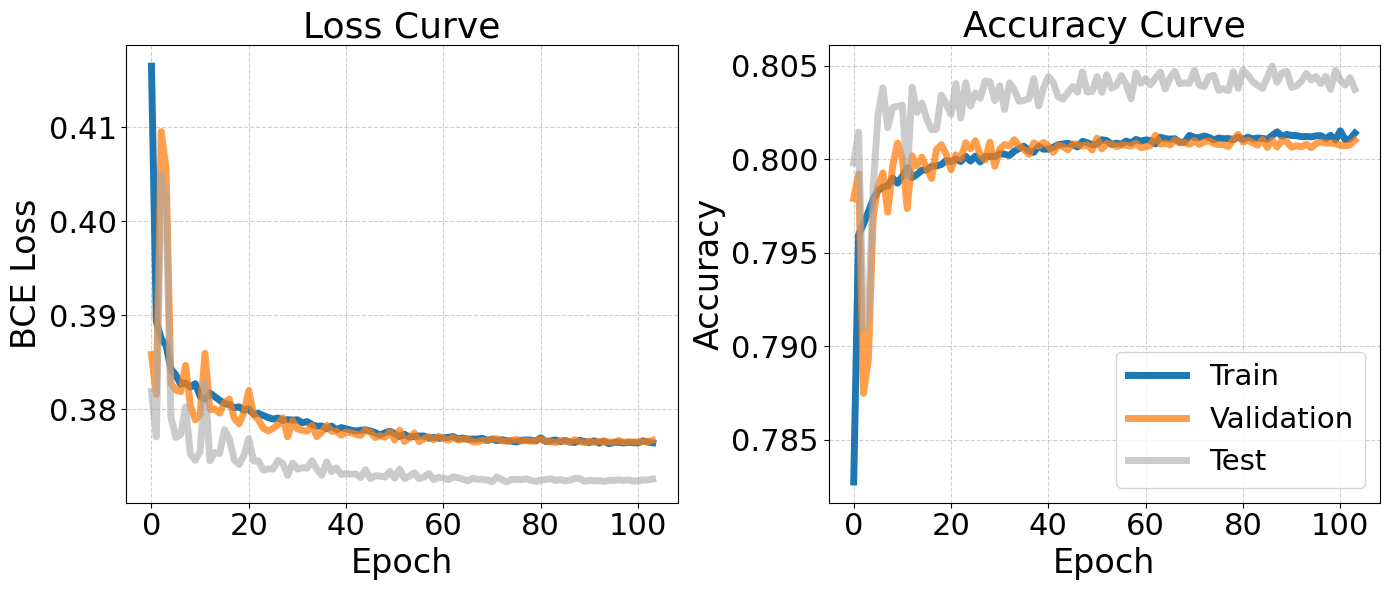

In [14]:
plot_training_summary(
    ckpt,
    #save_path=f"figures/...",
    alpha_train=1.0,
    alpha_val=0.75,
    alpha_test=0.6,
)

### Understanding Training vs Validation Loss

**Note:** It's normal for validation loss to be lower than training loss in this setup. This occurs because:

1. **Dropout (5%)**: Randomly disables neurons during training, adding noise and making training harder. Disabled during validation.
2. **Batch Normalization**: Uses batch statistics during training but running averages during validation, leading to more stable predictions.
3. **Model Modes**: `model.train()` enables regularization, while `model.eval()` disables it for more consistent inference.

This is a **sign of good regularization** working properly, not a problem. The model isn't overfitting and generalizes well to unseen data. Only worry if the gap becomes very large (>30%) or if validation loss increases over time.

## 3. Posterior Inference

Demonstrate inference capabilities by generating posterior distributions for given parameter combinations.

### Single Posterior Example

Generate a posterior for a specific WIMP mass and cross-section combination.

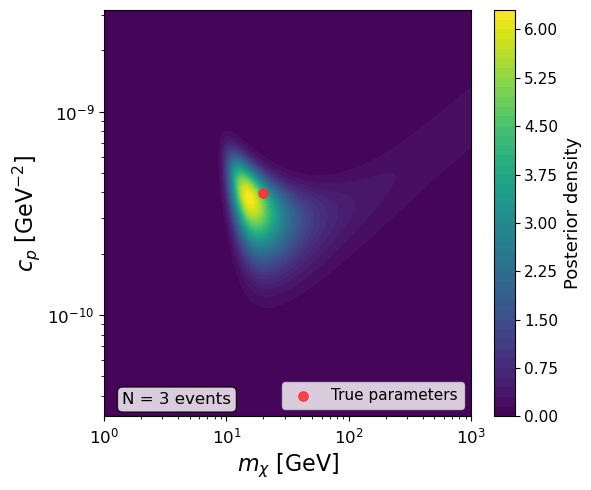

In [15]:
plot_posterior_single(
    model=model,
    mchi=20.0,
    cp=10**(-9.4),
    #credible_levels=[0.68, 0.95],  
    y_quantity="cp"
)

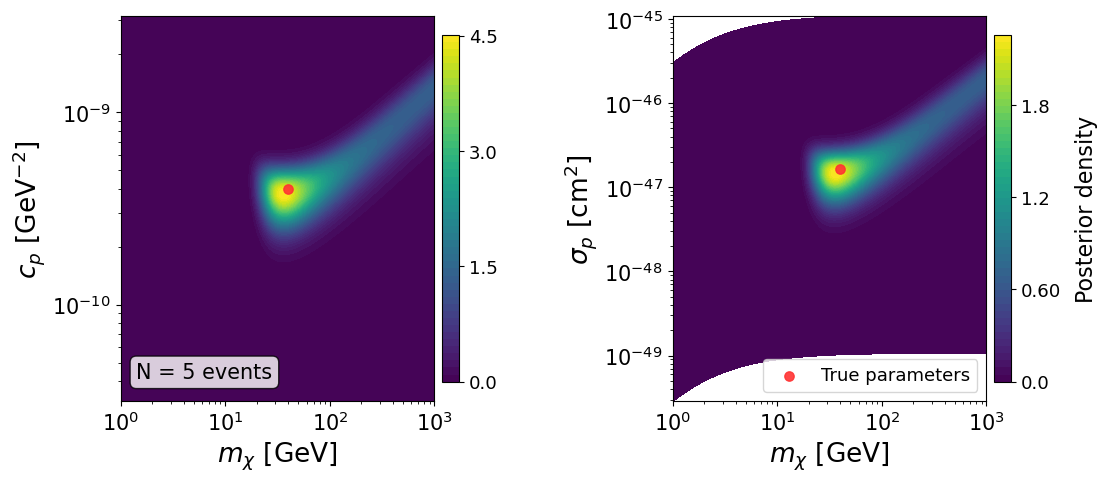

In [16]:
plot_posterior_double(
    model=model,
    mchi=40.0,
    cp=10**(-9.4),
    #credible_levels=[0.68, 0.95],
    #save_path=f"figures/..."
)   

### Grid of Posteriors

Generate multiple posteriors across a grid of parameter values to visualize how the model performs across different regions of parameter space.

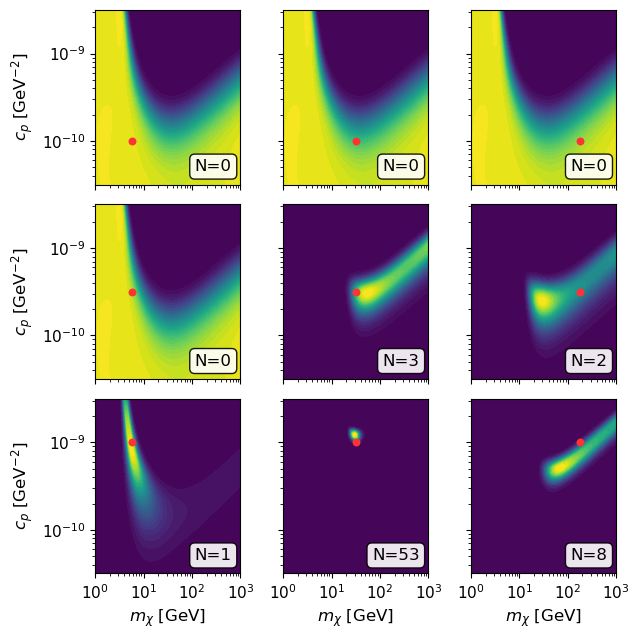

In [17]:
plot_posterior_grid(
    model=model,
    from_validation=True, val_loader=val_loader, stochastic=True,
    grid_dim=3, colorbar=False, 
    #save_path=f"figures/...",
    logm_range=logm_range, logcp_range=logcp_range,
)

## 4. HPD Credible-Region Exclusions

Use highest-posterior-density (HPD) credible regions to define exclusion curves.
This method finds the smallest-area region containing a given probability mass and extracts the boundary as an exclusion line.

### HPD Exclusion from Null Spectrum

Compute the HPD-based exclusion curve directly from the null posterior.

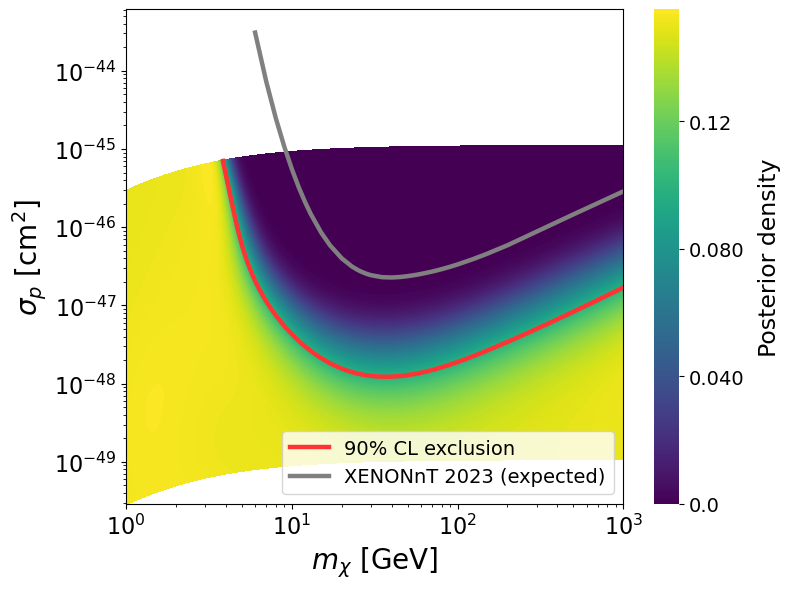

In [18]:
plot_null_exclusion(
    model=model,
    feature_template=feature_tensor[0],
    plot_official_xenonnt=True,
    y_quantity="sigma",
    #save_path=f"figures/...",
)